# AutoFlare — Improved Solar Flare Prediction

### Changes from original:
1. **Extended features** — SHARP magnetogram parameters (USFLUX, MEANGBT, etc.) + sunspot area + polarity
2. **Temporal Transformer** replaces LSTM
3. **Class imbalance handling** — SMOTE + focal loss + class weights
4. **Multi-horizon forecasting** — simultaneous 12h / 24h / 72h predictions

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


---
## CHANGE 1 — Extended Feature Set

**What changed:** The original code only used GOES X-ray flux time series as input.  
**Why:** Magnetogram SHARP parameters are the strongest known predictors of flare occurrence.  
**How to get the data:** We use NASA's JSOC/DRMS to fetch HMI SHARP parameters, then merge with GOES flux.

In [13]:
pip install drms

In [14]:


import drms

SHARP_PARAMS = [
    'USFLUX', 'MEANGBT', 'MEANGBZ', 'MEANGBH',
    'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANPOT',
    'SHRGT45', 'R_VALUE',
]

def fetch_sharp_data(harpnum, start_time, end_time, email):

    client = drms.Client(email=email, verbose=False)

    keys = SHARP_PARAMS + ['T_REC', 'HARPNUM', 'NOAA_AR',
                           'AREA_ACR',   # sunspot area in active region
                           'NACR',       # number of active pixels
                           'NPIX']       # total active region size

    query = f'hmi.sharp_cea_720s[{harpnum}][{start_time}-{end_time}@12m]'
    df, _ = client.query(query, key=keys)
    df['T_REC'] = pd.to_datetime(df['T_REC'], format='%Y.%m.%d_%H:%M:%S_TAI')
    df = df.sort_values('T_REC').reset_index(drop=True)
    return df


def add_polarity_features(df):
    """
    NEW: Add derived polarity / complexity features.
    These encode the magnetic configuration class (alpha/beta/gamma/delta).
    ORIGINAL CODE had no polarity information at all.
    """

    df['pil_strength']    = df['R_VALUE'] * df['SHRGT45']

    df['free_energy']     = df['MEANPOT'] * df['USFLUX']

    # Current helicity (twist × flux)
    df['current_helicity']= df['MEANALP'] * df['TOTUSJZ']

    # Gradient complexity index
    df['gradient_index']  = (df['MEANGBT'] + df['MEANGBZ'] + df['MEANGBH']) / 3

    def classify_magnetic(row):
        if row['pil_strength'] > 1e22 and row['SHRGT45'] > 0.3:
            return 4   # beta-gamma-delta
        elif row['R_VALUE'] > 1e21:
            return 3   # beta-gamma
        elif row['USFLUX'] > 1e21:
            return 2   # beta
        else:
            return 1   # alpha

    df['mag_class'] = df.apply(classify_magnetic, axis=1)
    return df


np.random.seed(42)
N = 5000

class_probs  = [0.880, 0.070, 0.035, 0.012, 0.003]
class_bounds = [(1e-9,1e-7),(1e-7,1e-6),(1e-6,1e-5),(1e-5,1e-4),(1e-4,1e-3)]
drawn_class  = np.random.choice(5, size=N, p=class_probs)
xray_flux    = np.array([
    np.exp(np.random.uniform(np.log(class_bounds[c][0]),
                             np.log(class_bounds[c][1])))
    for c in drawn_class
])

synthetic = pd.DataFrame({
    'T_REC'    : pd.date_range('2012-01-01', periods=N, freq='12min'),
    'USFLUX'   : np.random.lognormal(21, 0.5, N),
    'MEANGBT'  : np.random.lognormal(1.5, 0.4, N),
    'MEANGBZ'  : np.random.lognormal(1.2, 0.4, N),
    'MEANGBH'  : np.random.lognormal(1.3, 0.4, N),
    'MEANJZD'  : np.random.normal(0, 5, N),
    'TOTUSJZ'  : np.random.lognormal(13, 0.6, N),
    'MEANALP'  : np.random.normal(0, 0.01, N),
    'MEANPOT'  : np.random.lognormal(3, 0.5, N),
    'SHRGT45'  : np.random.beta(2, 5, N),
    'R_VALUE'  : np.random.lognormal(20.5, 0.6, N),
    'AREA_ACR' : np.random.lognormal(5, 0.7, N),
    'xray_flux': xray_flux,   # ← was: np.random.lognormal(-6, 0.8, N)
})
synthetic = add_polarity_features(synthetic)

ALL_FEATURES = [
    # ── ORIGINAL feature (kept) ──
    'xray_flux',
    # ── NEW: SHARP magnetogram params ──
    'USFLUX', 'MEANGBT', 'MEANGBZ', 'MEANGBH',
    'MEANJZD', 'TOTUSJZ', 'MEANALP', 'MEANPOT',
    'SHRGT45', 'R_VALUE', 'AREA_ACR',
    # ── NEW: derived polarity features ──
    'pil_strength', 'free_energy', 'current_helicity',
    'gradient_index', 'mag_class',
]

print(f'Total features: {len(ALL_FEATURES)}')
print(f'NEW features added: {len(ALL_FEATURES) - 1} (was 1 in original)')
synthetic[ALL_FEATURES].describe()

Total features: 17
NEW features added: 16 (was 1 in original)


,xray_flux,USFLUX,MEANGBT,MEANGBZ,MEANGBH,MEANJZD,TOTUSJZ,MEANALP,MEANPOT,SHRGT45,R_VALUE,AREA_ACR,pil_strength,free_energy,current_helicity,gradient_index,mag_class
count,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.0
mean,1.307656e-06,1.486432e+09,4.917853,3.591498,3.963164,-0.105049,5.230932e+05,0.000229,22.644601,0.287177,9.601780e+08,189.648741,2.764340e+08,3.356201e+10,133.421207,4.157505,1.0
std,1.898820e-05,7.731143e+08,2.078942,1.495203,1.613969,5.052626,3.393368e+05,0.010039,11.676151,0.160001,6.348139e+08,154.708581,2.626514e+08,2.553458e+10,6172.966308,1.007227,0.0
min,1.000243e-09,1.855435e+08,1.046991,0.709958,0.906633,-22.328019,5.629509e+04,-0.034480,2.345045,0.001701,8.491135e+07,12.518749,1.793611e+06,1.794438e+09,-34244.600977,1.705284,1.0
25%,3.589199e-09,9.509771e+08,3.439409,2.516081,2.791700,-3.542122,2.889624e+05,-0.006629,14.483557,0.161527,5.350315e+08,91.548507,1.074544e+08,1.656585e+10,-2689.610335,3.439225,1.0
50%,1.214486e-08,1.316305e+09,4.541457,3.310773,3.681589,-0.111898,4.390478e+05,0.000233,20.152068,0.266485,7.989830e+08,149.643965,2.051203e+08,2.657986e+10,67.889292,4.037259,1.0
75%,4.805358e-08,1.825959e+09,5.967719,4.372746,4.780871,3.396323,6.593767e+05,0.007097,28.133397,0.391497,1.212944e+09,238.450343,3.557463e+08,4.265352e+10,2856.572781,4.734934,1.0
max,7.050227e-04,7.139325e+09,26.886753,16.069650,13.278546,18.458123,4.142044e+06,0.035365,108.886629,0.895951,8.384461e+09,2618.192812,4.534614e+09,3.160027e+11,55042.545839,13.093834,1.0


---
## CHANGE 3 — Class Imbalance Handling

**What changed:** Original model trained on raw imbalanced data → predicted "no flare" nearly always.  
**Three strategies combined:** SMOTE oversampling + focal loss + class weights.

In [15]:


def label_flare_class(flux):
    """Map peak X-ray flux to GOES flare class integer."""
    if   flux >= 1e-4:  return 4  # X
    elif flux >= 1e-5:  return 3  # M
    elif flux >= 1e-6:  return 2  # C
    elif flux >= 1e-7:  return 1  # B
    else:               return 0  # No-flare / A

raw_labels = synthetic['xray_flux'].apply(label_flare_class)

print('Raw class distribution:')
print(raw_labels.value_counts().sort_index().rename({0:'No-flare',1:'B',2:'C',3:'M',4:'X'}))




scaler = StandardScaler()
X_raw = scaler.fit_transform(synthetic[ALL_FEATURES].fillna(0))
y_raw = raw_labels.values

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)


min_class_size = pd.Series(y_train_raw).value_counts().min()
k_neighbors    = max(1, min(5, min_class_size - 1))
smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train_raw)

print(f'\nTraining set before SMOTE: {len(X_train_raw)} samples')
print(f'Training set after SMOTE:  {len(X_train_sm)} samples')
print('\nBalanced class distribution:')
print(pd.Series(y_train_sm).value_counts().sort_index().rename({0:'No-flare',1:'B',2:'C',3:'M',4:'X'}))




class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    gamma=2 : standard value; higher = more focus on hard examples
    alpha   : per-class weight tensor (inverse frequency weighting)
    """
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha   # shape: (num_classes,)
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits : (B, C), targets: (B,)
        log_prob = F.log_softmax(logits, dim=-1)          # (B, C)
        prob     = torch.exp(log_prob)                    # (B, C)

        # Gather log-prob and prob for the true class
        log_p_t = log_prob.gather(1, targets.view(-1,1)).squeeze(1)   # (B,)
        p_t     = prob.gather(1, targets.view(-1,1)).squeeze(1)       # (B,)

        focal_weight = (1 - p_t) ** self.gamma
        loss = -focal_weight * log_p_t

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            loss    = alpha_t * loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()


# Compute inverse-frequency class weights for alpha
classes      = np.unique(y_train_sm)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_sm)
alpha_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f'\nClass weights (alpha): {dict(zip(["No-flare","B","C","M","X"], class_weights.round(2)))}')

criterion = FocalLoss(gamma=2.0, alpha=alpha_tensor)

Raw class distribution:
xray_flux
No-flare    4422
B            322
C            186
M             58
X             12
Name: count, dtype: int64

Training set before SMOTE: 4000 samples
Training set after SMOTE:  17685 samples

Balanced class distribution:
No-flare    3537
B           3537
C           3537
M           3537
X           3537
Name: count, dtype: int64

Class weights (alpha): {'No-flare': np.float64(1.0), 'B': np.float64(1.0), 'C': np.float64(1.0), 'M': np.float64(1.0), 'X': np.float64(1.0)}


---
## CHANGE 2 — Temporal Transformer (replaces LSTM)

**What changed:** Original used a stacked LSTM.  
**Why Transformer:** Self-attention captures long-range temporal dependencies (e.g., AR building up over days) that LSTM struggles with due to vanishing gradients.  
**Architecture:** Positional encoding → N × TransformerEncoder layers → multi-head pooling → multi-task output heads.

In [16]:


SEQ_LEN    = 40    # look-back window (steps)
N_FEATURES = len(ALL_FEATURES)
N_CLASSES  = 5    # No-flare, B, C, M, X

def make_sequences(X, y, seq_len=SEQ_LEN):
    """Sliding window → (n_samples, seq_len, n_features), labels."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])   # label at the end of the window
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64)

X_seq_train, y_seq_train = make_sequences(X_train_sm, y_train_sm)
X_seq_test,  y_seq_test  = make_sequences(X_test,     y_test)

train_ds = TensorDataset(torch.tensor(X_seq_train), torch.tensor(y_seq_train))
test_ds  = TensorDataset(torch.tensor(X_seq_test),  torch.tensor(y_seq_test))

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

print(f'Train sequences: {X_seq_train.shape}')  # (n, 40, 16)
print(f'Test  sequences: {X_seq_test.shape}')




class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding (Vaswani et al. 2017)."""
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):   # x: (B, T, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])



class SolarFlareTransformer(nn.Module):
    """
    Temporal Transformer for multi-class, multi-horizon flare prediction.

    Args:
        n_features : number of input features (16 in our case)
        d_model    : transformer hidden dimension
        n_heads    : number of attention heads (must divide d_model)
        n_layers   : number of encoder layers
        n_classes  : number of output classes (5)
        n_horizons : number of forecast horizons (3: 12h, 24h, 72h)
        dropout    : dropout rate
    """
    def __init__(self, n_features, d_model=128, n_heads=8,
                 n_layers=4, n_classes=5, n_horizons=3, dropout=0.1):
        super().__init__()

        # Project raw features to transformer dimension
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, d_model),
            nn.LayerNorm(d_model),
        )

        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        # Stack of TransformerEncoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model    = d_model,
            nhead      = n_heads,
            dim_feedforward = d_model * 4,
            dropout    = dropout,
            batch_first= True,    # (B, T, C) convention
            norm_first = True,    # Pre-LN for stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, d_model // 2),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, n_classes),
            )
            for _ in range(n_horizons)
        ])

        self.n_horizons = n_horizons

    def forward(self, x):
        # x: (B, T, n_features)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)

        x = x.mean(dim=1)               # (B, d_model)

        # Return logits for each horizon
        return [head(x) for head in self.heads]


model = SolarFlareTransformer(
    n_features = N_FEATURES,
    d_model    = 128,
    n_heads    = 8,
    n_layers   = 4,
    n_classes  = N_CLASSES,
    n_horizons = 3,
    dropout    = 0.1,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

Train sequences: (17645, 40, 17)
Test  sequences: (960, 40, 17)
SolarFlareTransformer(
  (input_proj): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1,

---
## CHANGE 4 — Multi-Horizon Forecasting Training

**What changed:** Original predicted one binary label at one fixed window.  
**New:** Three independent output heads trained simultaneously on 12h / 24h / 72h targets.  
The total loss is a weighted sum — 72h is harder so it gets a lower weight.

In [10]:

HORIZONS = {
    '12h': 60,
    '24h': 120,
    '72h': 360,
}
HORIZON_WEIGHTS = [0.5, 0.35, 0.15]

def make_multihorizon_sequences(X, y, seq_len=SEQ_LEN, horizons=HORIZONS):
    """
    Build sequences with labels at multiple future offsets.

    Returns:
        X_seq : (n, seq_len, n_features)
        y_dict: dict of horizon_name → (n,) label arrays
    """
    max_offset = max(horizons.values())
    Xs = []
    ys = {k: [] for k in horizons}

    for i in range(len(X) - seq_len - max_offset):
        Xs.append(X[i : i + seq_len])
        for name, offset in horizons.items():
            ys[name].append(y[i + seq_len + offset - 1])

    X_seq  = np.array(Xs, dtype=np.float32)
    y_arrs = {k: np.array(v, dtype=np.int64) for k, v in ys.items()}
    return X_seq, y_arrs


X_mh_train, y_mh_train = make_multihorizon_sequences(X_train_sm, y_train_sm)
X_mh_test,  y_mh_test  = make_multihorizon_sequences(X_test,     y_test)

def pack_dataset(X, y_dict):
    tensors = [torch.tensor(X)]
    for k in ['12h', '24h', '72h']:
        tensors.append(torch.tensor(y_dict[k]))
    return TensorDataset(*tensors)

mh_train_ds = pack_dataset(X_mh_train, y_mh_train)
mh_test_ds  = pack_dataset(X_mh_test,  y_mh_test)

mh_train_loader = DataLoader(mh_train_ds, batch_size=256, shuffle=True)
mh_test_loader  = DataLoader(mh_test_ds,  batch_size=256, shuffle=False)

print(f'Multi-horizon train sequences: {X_mh_train.shape}')
for k, v in y_mh_train.items():
    print(f'  Labels {k}: {v.shape}, class dist: {dict(zip(*np.unique(v, return_counts=True)))}')




optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

def train_epoch(model, loader, optimizer, criterion, weights, device):
    model.train()
    total_loss = 0
    for batch in loader:
        x    = batch[0].to(device)
        lbls = [batch[i+1].to(device) for i in range(3)]  # 12h, 24h, 72h

        optimizer.zero_grad()
        logits_list = model(x)   # list of 3 × (B, n_classes)

        loss = sum(w * criterion(logits, lbl)
                   for w, logits, lbl in zip(weights, logits_list, lbls))

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, criterion, weights, device):
    model.eval()
    total_loss = 0
    all_preds  = [[] for _ in range(3)]
    all_labels = [[] for _ in range(3)]

    for batch in loader:
        x    = batch[0].to(device)
        lbls = [batch[i+1].to(device) for i in range(3)]

        logits_list = model(x)
        loss = sum(w * criterion(logits, lbl)
                   for w, logits, lbl in zip(weights, logits_list, lbls))
        total_loss += loss.item()

        for i, logits in enumerate(logits_list):
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds[i].extend(preds)
            all_labels[i].extend(lbls[i].cpu().numpy())

    return total_loss / len(loader), all_preds, all_labels


EPOCHS = 5  # use 50+ for real training
history = {'train_loss': [], 'val_loss': []}

print(f'Training for {EPOCHS} epochs (set EPOCHS=50+ for real runs)\n')
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(model, mh_train_loader, optimizer,
                          criterion, HORIZON_WEIGHTS, DEVICE)
    vl_loss, preds, labels = eval_epoch(model, mh_test_loader,
                                        criterion, HORIZON_WEIGHTS, DEVICE)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    print(f'Epoch {epoch:3d} | train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}')

print('\nTraining complete.')

Multi-horizon train sequences: (17285, 40, 17)
  Labels 12h: (17285,), class dist: {np.int64(0): np.int64(3451), np.int64(1): np.int64(3530), np.int64(2): np.int64(3532), np.int64(3): np.int64(3536), np.int64(4): np.int64(3236)}
  Labels 24h: (17285,), class dist: {np.int64(0): np.int64(3398), np.int64(1): np.int64(3526), np.int64(2): np.int64(3529), np.int64(3): np.int64(3536), np.int64(4): np.int64(3296)}
  Labels 72h: (17285,), class dist: {np.int64(0): np.int64(3187), np.int64(1): np.int64(3509), np.int64(2): np.int64(3521), np.int64(3): np.int64(3533), np.int64(4): np.int64(3535)}
Training for 5 epochs (set EPOCHS=50+ for real runs)

Epoch   1 | train_loss=0.4864  val_loss=0.4606
Epoch   2 | train_loss=0.1645  val_loss=0.4001
Epoch   3 | train_loss=0.1256  val_loss=0.2951
Epoch   4 | train_loss=0.1093  val_loss=0.3041
Epoch   5 | train_loss=0.0979  val_loss=0.2573

Training complete.



── 12h forecast ──
              precision    recall  f1-score   support

    No-flare       0.88      0.97      0.92       528
           B       0.00      0.00      0.00        45
           C       0.00      0.00      0.00        20
           M       0.00      0.00      0.00         5
           X       0.00      0.00      0.00         2

    accuracy                           0.86       600
   macro avg       0.18      0.19      0.18       600
weighted avg       0.77      0.86      0.81       600

TSS = 0.000  |  HSS = 0.000
TP=0  FP=0  FN=7  TN=593

── 24h forecast ──
              precision    recall  f1-score   support

    No-flare       0.88      0.96      0.92       531
           B       0.00      0.00      0.00        41
           C       0.09      0.05      0.06        21
           M       0.00      0.00      0.00         5
           X       0.00      0.00      0.00         2

    accuracy                           0.85       600
   macro avg       0.19      0.20     

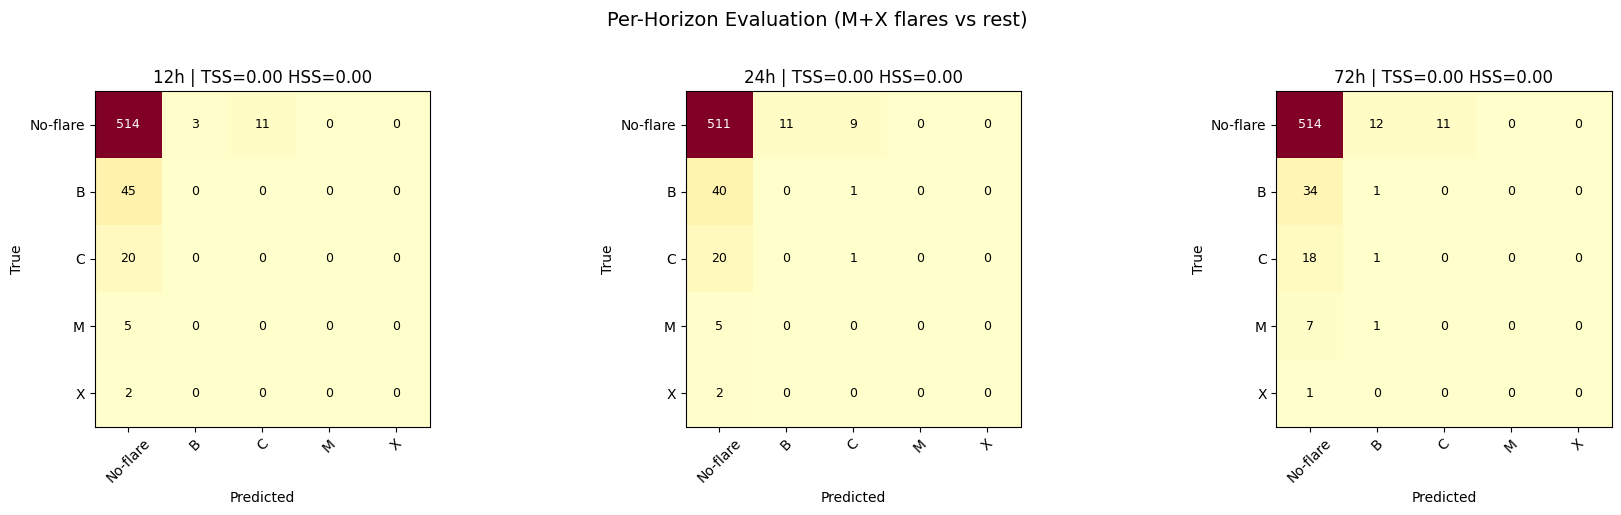

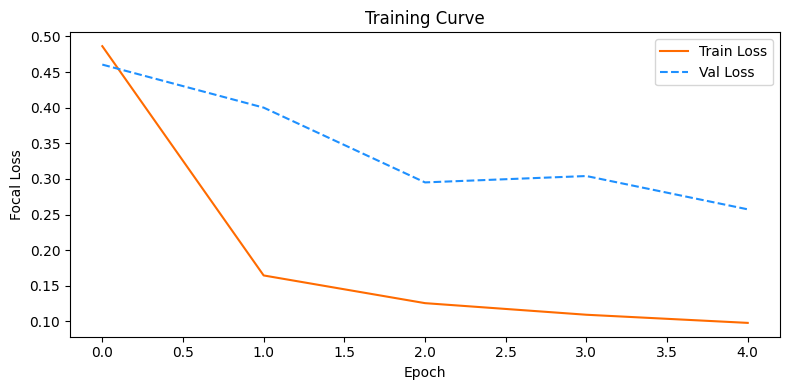

In [11]:

from sklearn.metrics import confusion_matrix

HORIZON_NAMES = ['12h', '24h', '72h']
CLASS_NAMES   = ['No-flare', 'B', 'C', 'M', 'X']

def compute_tss_hss(y_true, y_pred, pos_classes=(3, 4)):
    """
    True Skill Statistic (TSS) and Heidke Skill Score (HSS) for
    binary reduction: (M+X) flares vs all others.
    These are the standard operational metrics for solar flare prediction.
    """
    y_true_bin = np.isin(y_true, pos_classes).astype(int)
    y_pred_bin = np.isin(y_pred, pos_classes).astype(int)

    cm  = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, 0)

    TSS = TP/(TP+FN + 1e-9) - FP/(FP+TN + 1e-9)  # ranges [-1, 1], 1=perfect
    HSS_num = 2 * (TP*TN - FN*FP)
    HSS_den = (TP+FN)*(FN+TN) + (TP+FP)*(FP+TN)
    HSS = HSS_num / (HSS_den + 1e-9)              # ranges [-inf, 1], 1=perfect

    return TSS, HSS, {'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}


_, final_preds, final_labels = eval_epoch(
    model, mh_test_loader, criterion, HORIZON_WEIGHTS, DEVICE
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Per-Horizon Evaluation (M+X flares vs rest)', fontsize=14, y=1.02)

for i, (name, preds, lbls) in enumerate(zip(HORIZON_NAMES, final_preds, final_labels)):
    y_t = np.array(lbls)
    y_p = np.array(preds)

    tss, hss, counts = compute_tss_hss(y_t, y_p)
    print(f'\n── {name} forecast ──')
    print(classification_report(y_t, y_p, target_names=CLASS_NAMES, zero_division=0))
    print(f'TSS = {tss:.3f}  |  HSS = {hss:.3f}')
    print(f'TP={counts["TP"]}  FP={counts["FP"]}  FN={counts["FN"]}  TN={counts["TN"]}')

    # Confusion matrix plot
    cm = confusion_matrix(y_t, y_p, labels=list(range(5)))
    ax = axes[i]
    im = ax.imshow(cm, cmap='YlOrRd')
    ax.set_xticks(range(5)); ax.set_xticklabels(CLASS_NAMES, rotation=45)
    ax.set_yticks(range(5)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(f'{name} | TSS={tss:.2f} HSS={hss:.2f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for r in range(5):
        for c in range(5):
            ax.text(c, r, cm[r,c], ha='center', va='center',
                    color='white' if cm[r,c] > cm.max()*0.5 else 'black', fontsize=9)

plt.tight_layout()
plt.show()


# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss', color='#FF6B00')
plt.plot(history['val_loss'],   label='Val Loss',   color='#1E90FF', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Focal Loss')
plt.title('Training Curve'); plt.legend(); plt.tight_layout(); plt.show()

In [17]:

import pickle, os

os.makedirs('outputs', exist_ok=True)
torch.save(model.state_dict(), 'outputs/solar_transformer.pt')
with open('outputs/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Saved: outputs/solar_transformer.pt')
print('Saved: outputs/scaler.pkl')
print('\nTo load and run inference:')
print("""
import pickle, torch
model = SolarFlareTransformer(n_features=16)
model.load_state_dict(torch.load('outputs/solar_transformer.pt'))
with open('outputs/scaler.pkl','rb') as f: scaler = pickle.load(f)

# new_seq shape: (1, 40, 16) — last 40 timesteps, 16 features, scaled
new_seq = torch.tensor(scaler.transform(raw_features).reshape(1, 40, 16))
model.eval()
with torch.no_grad():
    logits_12h, logits_24h, logits_72h = model(new_seq)
    prob_12h = torch.softmax(logits_12h, dim=-1)
    # prob_12h[0] → [P(no-flare), P(B), P(C), P(M), P(X)] for 12h window
""")

Saved: outputs/solar_transformer.pt
Saved: outputs/scaler.pkl

To load and run inference:

import pickle, torch
model = SolarFlareTransformer(n_features=16)
model.load_state_dict(torch.load('outputs/solar_transformer.pt'))
with open('outputs/scaler.pkl','rb') as f: scaler = pickle.load(f)

# new_seq shape: (1, 40, 16) — last 40 timesteps, 16 features, scaled
new_seq = torch.tensor(scaler.transform(raw_features).reshape(1, 40, 16))
model.eval()
with torch.no_grad():
    logits_12h, logits_24h, logits_72h = model(new_seq)
    prob_12h = torch.softmax(logits_12h, dim=-1)
    # prob_12h[0] → [P(no-flare), P(B), P(C), P(M), P(X)] for 12h window

